This classifier should only classify  the slices where a pathology can be seen.

In [109]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import pydicom
from PIL import Image
from tqdm import tqdm
import timm
import pickle

DATA_PATH = "D:/ML/RSNA2024"

In [110]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


## Data Processing

In [111]:
df = pd.read_csv(os.path.join(DATA_PATH, "train.csv"))
df = df.fillna("Normal/Mild")
df.set_index("study_id", inplace=True)
df.head(10)

,spinal_canal_stenosis_l1_l2,spinal_canal_stenosis_l2_l3,spinal_canal_stenosis_l3_l4,spinal_canal_stenosis_l4_l5,spinal_canal_stenosis_l5_s1,left_neural_foraminal_narrowing_l1_l2,left_neural_foraminal_narrowing_l2_l3,left_neural_foraminal_narrowing_l3_l4,left_neural_foraminal_narrowing_l4_l5,left_neural_foraminal_narrowing_l5_s1,...,left_subarticular_stenosis_l1_l2,left_subarticular_stenosis_l2_l3,left_subarticular_stenosis_l3_l4,left_subarticular_stenosis_l4_l5,left_subarticular_stenosis_l5_s1,right_subarticular_stenosis_l1_l2,right_subarticular_stenosis_l2_l3,right_subarticular_stenosis_l3_l4,right_subarticular_stenosis_l4_l5,right_subarticular_stenosis_l5_s1
study_id,,,,,,,,,,,,,,,,,,,,,
4003253,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
4646740,Normal/Mild,Normal/Mild,Moderate,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate,Normal/Mild
7143189,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
8785691,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
10728036,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild
11340341,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild
11943292,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild
13317052,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Severe,...,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Moderate
22191399,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,Normal/Mild,...,Normal/Mild,Normal/Mild,Normal/Mild,Moderate,Moderate,Normal/Mild,Normal/Mild,Normal/Mild,Severe,Moderate


In [112]:
pd.unique(df["spinal_canal_stenosis_l1_l2"])

array(['Normal/Mild', 'Moderate', 'Severe'], dtype=object)

In [113]:
dfCoord = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoord.set_index(["study_id", "series_id"], inplace=True)
dfCoord.head(20)

instance_number                         condition  level  \
study_id series_id                                                              
4003253  702807833                 8             Spinal Canal Stenosis  L1/L2   
         702807833                 8             Spinal Canal Stenosis  L2/L3   
         702807833                 8             Spinal Canal Stenosis  L3/L4   
         702807833                 8             Spinal Canal Stenosis  L4/L5   
         702807833                 8             Spinal Canal Stenosis  L5/S1   
         1054713880                4  Right Neural Foraminal Narrowing  L4/L5   
         1054713880                4  Right Neural Foraminal Narrowing  L5/S1   
         1054713880                5  Right Neural Foraminal Narrowing  L3/L4   
         1054713880                6  Right Neural Foraminal Narrowing  L1/L2   
         1054713880                6  Right Neural Foraminal Narrowing  L2/L3   
         1054713880               11   Left Neural Foraminal Narrowing  L1/L2   
         1054713880               11   Left Neural Foraminal Narrowing  L4/L5   
         1054713880               11   Left Neural Foraminal Narrowing  L5/S1   
         1054713880               12   Left Neural Foraminal Narrowing  L2/L3   
         1054713880               12   Left Neural Foraminal Narrowing  L3/L4   
         2448190387                3        Left Subarticular Stenosis  L1/L2   
         2448190387                4       Right Subarticular Stenosis  L1/L2   
         2448190387               11        Left Subarticular Stenosis  L2/L3   
         2448190387               11       Right Subarticular Stenosis  L2/L3   
         2448190387               19        Left Subarticular Stenosis  L3/L4   

                              x           y  
study_id series_id                           
4003253  702807833   322.831858  227.964602  
         702807833   320.571429  295.714286  
         702807833   323.030303  371.818182  
         702807833   335.292035  427.327434  
         702807833   353.415929  483.964602  
         1054713880  187.961759  251.839388  
         1054713880  198.240918  285.613767  
         1054713880  187.227533  210.722753  
         1054713880  194.569790  127.755258  
         1054713880  191.632887  165.934990  
         1054713880  196.070671  126.021201  
         1054713880  186.504472  251.592129  
         1054713880  197.100569  289.457306  
         1054713880  191.321555  170.120141  
         1054713880  187.878354  217.245081  
         2448190387  179.126448  161.235521  
         2448190387  145.288771  158.624642  
         2448190387  180.979730  158.764479  
         2448190387  145.900042  157.096466  
         2448190387  176.037645  157.528958

In [114]:
dfCoordIdx = pd.read_csv(os.path.join(DATA_PATH, "train_label_coordinates.csv"))
dfCoordIdx.set_index(["study_id", "series_id", "instance_number"], inplace=True)
uniqueStudSerInst = dfCoordIdx.index.unique()
uniqueStudSerInst

MultiIndex([(   4003253,  702807833,  8),
            (   4003253, 1054713880,  4),
            (   4003253, 1054713880,  5),
            (   4003253, 1054713880,  6),
            (   4003253, 1054713880, 11),
            (   4003253, 1054713880, 12),
            (   4003253, 2448190387,  3),
            (   4003253, 2448190387,  4),
            (   4003253, 2448190387, 11),
            (   4003253, 2448190387, 19),
            ...
            (4290709089, 3390218084,  5),
            (4290709089, 3390218084,  6),
            (4290709089, 3390218084, 10),
            (4290709089, 3390218084, 15),
            (4290709089, 3390218084, 20),
            (4290709089, 3390218084, 21),
            (4290709089, 4237840455,  4),
            (4290709089, 4237840455,  5),
            (4290709089, 4237840455, 11),
            (4290709089, 4237840455, 12)],
           names=['study_id', 'series_id', 'instance_number'], length=24546)

In [115]:
dfCoordIdx.head(20)

condition  level  \
study_id series_id  instance_number                                            
4003253  702807833  8                           Spinal Canal Stenosis  L1/L2   
                    8                           Spinal Canal Stenosis  L2/L3   
                    8                           Spinal Canal Stenosis  L3/L4   
                    8                           Spinal Canal Stenosis  L4/L5   
                    8                           Spinal Canal Stenosis  L5/S1   
         1054713880 4                Right Neural Foraminal Narrowing  L4/L5   
                    4                Right Neural Foraminal Narrowing  L5/S1   
                    5                Right Neural Foraminal Narrowing  L3/L4   
                    6                Right Neural Foraminal Narrowing  L1/L2   
                    6                Right Neural Foraminal Narrowing  L2/L3   
                    11                Left Neural Foraminal Narrowing  L1/L2   
                    11                Left Neural Foraminal Narrowing  L4/L5   
                    11                Left Neural Foraminal Narrowing  L5/S1   
                    12                Left Neural Foraminal Narrowing  L2/L3   
                    12                Left Neural Foraminal Narrowing  L3/L4   
         2448190387 3                      Left Subarticular Stenosis  L1/L2   
                    4                     Right Subarticular Stenosis  L1/L2   
                    11                     Left Subarticular Stenosis  L2/L3   
                    11                    Right Subarticular Stenosis  L2/L3   
                    19                     Left Subarticular Stenosis  L3/L4   

                                              x           y  
study_id series_id  instance_number                          
4003253  702807833  8                322.831858  227.964602  
                    8                320.571429  295.714286  
                    8                323.030303  371.818182  
                    8                335.292035  427.327434  
                    8                353.415929  483.964602  
         1054713880 4                187.961759  251.839388  
                    4                198.240918  285.613767  
                    5                187.227533  210.722753  
                    6                194.569790  127.755258  
                    6                191.632887  165.934990  
                    11               196.070671  126.021201  
                    11               186.504472  251.592129  
                    11               197.100569  289.457306  
                    12               191.321555  170.120141  
                    12               187.878354  217.245081  
         2448190387 3                179.126448  161.235521  
                    4                145.288771  158.624642  
                    11               180.979730  158.764479  
                    11               145.900042  157.096466  
                    19               176.037645  157.528958

In [116]:
allConditions = pd.unique(dfCoord["condition"])
allLevels = pd.unique(dfCoord["level"])
allLabels = np.array(df.columns)

labelMapping = {"Normal/Mild": 0, "Moderate":1, "Severe":2}

In [117]:
allLabelsMapping = dict(zip(allLabels,np.arange(0,len(allLabels),1)))
allLabelsMapping

{'spinal_canal_stenosis_l1_l2': 0,
 'spinal_canal_stenosis_l2_l3': 1,
 'spinal_canal_stenosis_l3_l4': 2,
 'spinal_canal_stenosis_l4_l5': 3,
 'spinal_canal_stenosis_l5_s1': 4,
 'left_neural_foraminal_narrowing_l1_l2': 5,
 'left_neural_foraminal_narrowing_l2_l3': 6,
 'left_neural_foraminal_narrowing_l3_l4': 7,
 'left_neural_foraminal_narrowing_l4_l5': 8,
 'left_neural_foraminal_narrowing_l5_s1': 9,
 'right_neural_foraminal_narrowing_l1_l2': 10,
 'right_neural_foraminal_narrowing_l2_l3': 11,
 'right_neural_foraminal_narrowing_l3_l4': 12,
 'right_neural_foraminal_narrowing_l4_l5': 13,
 'right_neural_foraminal_narrowing_l5_s1': 14,
 'left_subarticular_stenosis_l1_l2': 15,
 'left_subarticular_stenosis_l2_l3': 16,
 'left_subarticular_stenosis_l3_l4': 17,
 'left_subarticular_stenosis_l4_l5': 18,
 'left_subarticular_stenosis_l5_s1': 19,
 'right_subarticular_stenosis_l1_l2': 20,
 'right_subarticular_stenosis_l2_l3': 21,
 'right_subarticular_stenosis_l3_l4': 22,
 'right_subarticular_stenosis_l4_l

In [118]:
def getLabelVector(studyId, seriesId, instanceNumber):
    labelVec = np.zeros_like(allLabels)
    try:
        pathologicalData = dfCoordIdx.loc[(studyId, seriesId, instanceNumber)]
    except KeyError:
        return labelVec
    
    # pathologicalData = pathologicalData[pathologicalData["instance_number"]==instanceNumber]
    if pathologicalData.size == 0:
        return labelVec
    
    for index, row in pathologicalData.iterrows():
        condition = row["condition"].lower().replace(" ","_")
        level = row["level"].lower().replace("/", "_")
        idx = allLabelsMapping[f"{condition}_{level}"]
        # print(f"{condition}_{level}")
        severity = df.loc[studyId][f"{condition}_{level}"]
        labelVec[idx] = labelMapping[severity]

    return labelVec

getLabelVector(4003253, 1054713880, 12)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0], dtype=object)

In [119]:
allFiles = []

for root, dirs, files in os.walk(os.path.join(DATA_PATH, "train_images")):
    for f in files:
        if f.endswith(".dcm"):
            allFiles.append(os.path.join(root,f))

len(allFiles)

147218

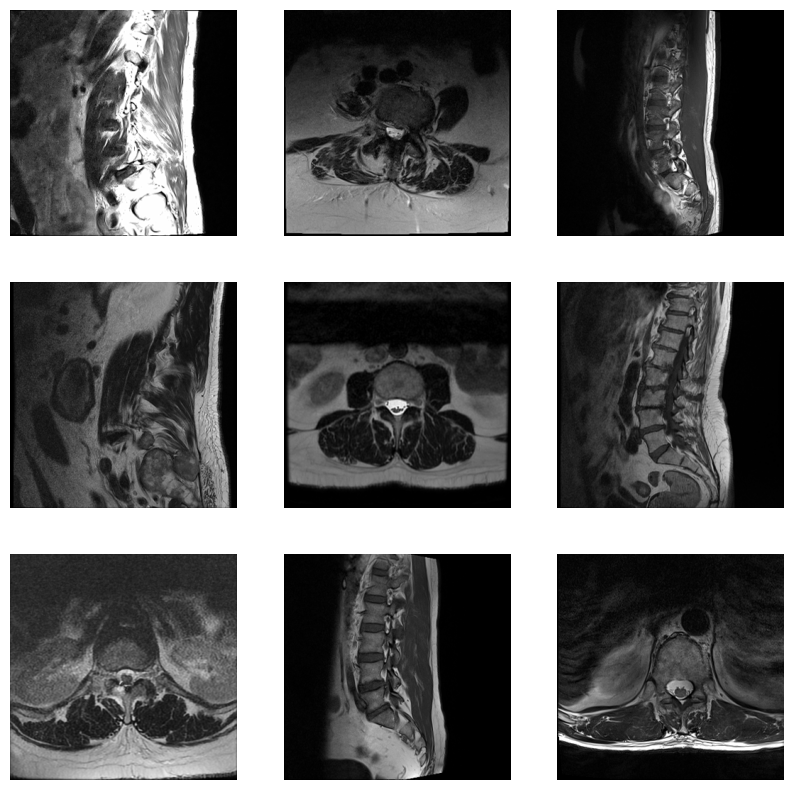

In [120]:
IMG_SIZE = (320, 320)
eps=1e-12

def dicomToArray(path):
    dicom = pydicom.read_file(path)
    data = pydicom.pixel_data_handlers.util.apply_modality_lut(dicom.pixel_array, dicom)
    data = pydicom.pixel_data_handlers.util.apply_windowing(data, dicom)
    # data = dicom.pixel_array
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        data = np.amax(data) - data
        
    w, h = data.shape[0], data.shape[1]

    #Center crop
    if w>h:
        diff = w-h
        data = data[diff//2:diff//2+h, :]
    if h>w:
        diff = h-w
        data = data[:, diff//2:diff//2+w]

    data = data - np.min(data)
    data = data * 1.0/(np.max(data)+eps)

    w, h = data.shape[0], data.shape[1]

    # resize
    if not (w == IMG_SIZE[0] and h == IMG_SIZE[1]):
        data = np.array(Image.fromarray((data * 255).astype(np.uint8), mode="L").resize(IMG_SIZE))

    # data = (data * 255).astype(np.uint8)
    return data


# plt.figure(figsize=(10,10))
# _ = plt.imshow(dicomToArray(os.path.join(DATA_PATH, "test_images/44036939/2828203845/15.dcm")), cmap="gray")
# _ = plt.colorbar()

plt.figure(figsize=(10,10))
for i,filePath in enumerate(np.random.choice(allFiles, 9)):
    plt.subplot(3,3, i+1)
    _ = plt.imshow(dicomToArray(filePath), cmap="gray")
    _ = plt.axis("off")
# plt.colorbar()

## Dataset

In [121]:
TRAIN_TEST_SPLIT = 0.7

allStudyIds = np.unique(df.index)
print(allStudyIds)

np.random.seed(5880)
np.random.shuffle(allStudyIds)
print(allStudyIds)

split = int(len(allStudyIds)*TRAIN_TEST_SPLIT)
print("# Training samples:",split)

trainStudyIds = allStudyIds[0:split]
valStudyIds = allStudyIds[split:]


[   4003253    4646740    7143189 ... 4284048608 4287160193 4290709089]
[3587842489  247968996 3336194522 ... 4279833491 3168755174 1722603252]
# Training samples: 1382


In [122]:
if os.path.exists(os.path.join(DATA_PATH,"./dataCC.pkl")):
    with open(os.path.join(DATA_PATH,"./dataCC.pkl"), "rb") as f:
        dictData = pickle.load(f)
        XTrain,yTrain,XVal,yVal = dictData["XTrain"], dictData["yTrain"],dictData["XVal"],dictData["yVal"]
else:
    XTrain=[]
    XVal=[]
    yTrain=[]
    yVal=[]
    for i,filePath in enumerate(tqdm(allFiles)):
        parts = filePath.split("\\")
        instance = int(parts[-1].replace(".dcm", ""))
        seriesId = int(parts[-2])
        studyId = int(parts[-3])
        labelVec = getLabelVector(studyId, seriesId, instance)
        if not (studyId, seriesId, instance) in uniqueStudSerInst:
            continue
        im = dicomToArray(os.path.join(DATA_PATH, filePath))

        if studyId in trainStudyIds:
            XTrain.append(im)
            yTrain.append(labelVec)
        elif studyId in valStudyIds:
            XVal.append(im)
            yVal.append(labelVec)
        else:
            raise Exception(f"Wrong study id {studyId}")
            
    with open(os.path.join(DATA_PATH,"./dataCC.pkl"), "wb") as f:
        pickle.dump({"XTrain":XTrain, "yTrain":yTrain, "XVal":XVal, "yVal": yVal}, f)

print(len(XTrain))
print(len(XVal))
print(XTrain[0].shape)
print(yTrain[0])

100%|██████████| 147218/147218 [15:02<00:00, 163.16it/s]


17141
7405
(320, 320)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [124]:
from torchvision.transforms import v2

transforms = v2.Compose([
    # v2.RandomHorizontalFlip(p=0.5),
    # v2.RandomVerticalFlip(p=0.5),
    v2.Grayscale(3),
    # v2.RandomResizedCrop(IMG_SIZE, (0.2,0.6), (0.8,1.2)),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transformsVal = v2.Compose([
    v2.Grayscale(3),
    v2.Resize(IMG_SIZE),
    v2.ToDtype(torch.float32),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


import random
random.seed(5584)
trainData = list(zip(XTrain,yTrain))
random.shuffle(trainData)
valData = list(zip(XVal,yVal))
random.shuffle(valData)


# trainData = trainData[0:300]
# valData = valData[0:300]

def generator():
    for im, label in trainData:
        im = np.expand_dims(im,0)
        im = im.astype(np.float32)/255.0
        im = transforms(torch.Tensor(im))
        yield im, np.array(label).astype(np.int64)


def generatorVal():
    for imVal, labelVal in valData:
        imVal = np.expand_dims(imVal,0)
        imVal = imVal.astype(np.float32)/255.0
        imVal = transformsVal(torch.Tensor(imVal))
        yield imVal, np.array(labelVal).astype(np.int64)

# def generatorAll():
#     for id in allIds:
#         yield getData(id)

tensor(-2.1179) tensor(-1.7870)
torch.Size([3, 320, 320])
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[]


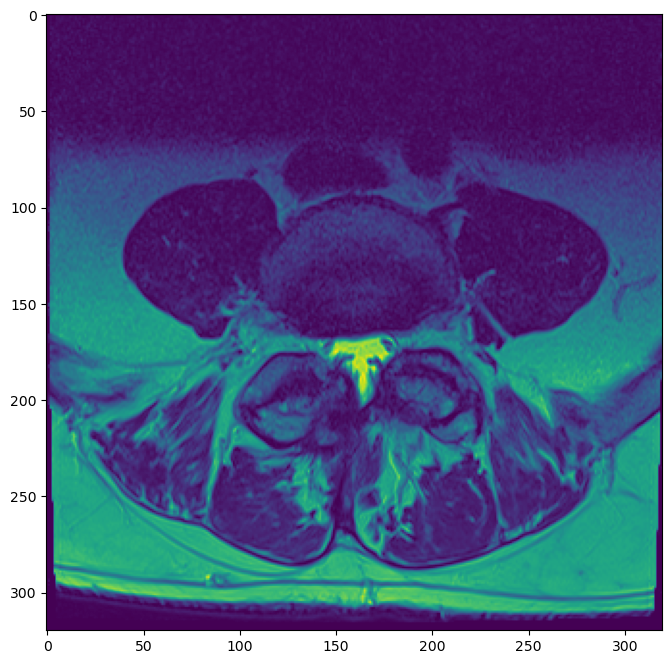

In [130]:
g = generator()
gVal = generatorVal()
testInstance = next(g)
testInstanceVal = next(gVal)

plt.figure(figsize=(8,8))
plt.imshow((testInstance[0][0,:,:]*0.225)+0.485, cmap="viridis")
print(torch.min(testInstance[0]), torch.max(testInstance[0]))
print(testInstance[0].shape)
print(testInstance[1])
print(allLabels[testInstance[1]>0])

In [131]:
BATCH_SIZE = 32

class IterDataset(torch.utils.data.IterableDataset):
    def __init__(self, generator, length):
        self.generator = generator
        self.len = length

    def __iter__(self):
        return self.generator()
    
    def __len__(self):
        return self.len
    
dataset = IterDataset(generator, len(trainData))
datasetVal = IterDataset(generatorVal, len(valData))

trainLoader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)
valLoader = torch.utils.data.DataLoader(datasetVal, batch_size=BATCH_SIZE, shuffle=False)

In [132]:
for XData, targets in trainLoader:
# for X, targets, targetsE,targetsK,targetsL,targetsS, patIds in trainLoader:
    print(f"Shape of X: {XData.shape} {XData.dtype}")
    print("Max and Min: ", torch.max(XData), torch.min(XData))
    print(f"Shape of target: {targets.shape} {targets.dtype}")
    break

Shape of X: torch.Size([32, 3, 320, 320]) torch.float32
Max and Min:  tensor(2.6400) tensor(-2.1179)
Shape of target: torch.Size([32, 25]) torch.int64


In [133]:
idx=4
print(targets[idx])
# plt.figure(figsize=(12,12))
# plt.imshow(XData[idx,:,:,:])
# _=plt.axis("off")

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0])


## Model

In [134]:
testF = torch.nn.CrossEntropyLoss()
# 8 Instances and 3 classes (0,1,2)
targetsTest = torch.Tensor([[0,2,0,1,0,2,0,1]]).type(torch.LongTensor) 
predsTest = torch.randn((1,3,8)).type(torch.float64)
print(predsTest)
testF(predsTest, targetsTest)

tensor([[[-1.6390, -0.0579,  1.0294, -0.2793, -0.7589,  0.1780,  0.3932,
           0.4962],
         [ 0.1035,  1.0668, -0.6883, -0.0818,  2.2595, -0.3244,  1.3561,
           0.0454],
         [ 0.7741, -0.1928, -0.5206,  1.0733,  0.1403,  0.7274,  1.0240,
           0.9801]]], dtype=torch.float64)


tensor(1.7156, dtype=torch.float64)

In [135]:
import torchinfo


# model = timm.create_model('edgenext_base', pretrained=True, num_classes=len(allLabels)*len(labelMapping))
# model.name = f"edgenext_base_{IMG_SIZE[0]}"

# model = timm.create_model('resnet34d', pretrained=True, num_classes=len(enc.classes_))
# model.name = "resnet34d_384_wang"

# model = timm.create_model('rexnet_150', pretrained=True, num_classes=len(enc.classes_))
# model.name = "RexNet150"

class EdgeNext(torch.nn.Module):
    def __init__(self):
        super(EdgeNext, self).__init__()
        self.name="PathClassifierSingleEdgeNext"

        self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=len(allLabels)*len(labelMapping))
        # self.basemodel = timm.create_model('edgenext_base', pretrained=True, num_classes=0)
        # self.flatten = torch.nn.Flatten()
        # self.linear2 = torch.nn.Linear(37376, len(allLabels)*len(labelMapping))
        # self.softmax = torch.nn.Softmax(dim=1)

    def forward(self, x):
        x = self.basemodel(x)
        # x = self.basemodel.forward_features(x)
        # x = self.flatten(x)
        # x = self.linear2(x)
        x = torch.reshape(x, (x.shape[0], len(labelMapping), len(allLabels)))
        # x = self.softmax(x)
        return x

model = EdgeNext()

from torchview import draw_graph

model_graph = draw_graph(model, input_size=(BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]), expand_nested=True)
model = model.to(device)
torchinfo.summary(model, input_size=[BATCH_SIZE,3,IMG_SIZE[0],IMG_SIZE[1]])

Layer (type:depth-idx)                                            Output Shape              Param #
EdgeNext                                                          [32, 3, 25]               --
├─EdgeNeXt: 1-1                                                   [32, 75]                  --
│    └─Sequential: 2-1                                            [32, 80, 80, 80]          --
│    │    └─Conv2d: 3-1                                           [32, 80, 80, 80]          3,920
│    │    └─LayerNorm2d: 3-2                                      [32, 80, 80, 80]          160
│    └─Sequential: 2-2                                            [32, 584, 10, 10]         --
│    │    └─EdgeNeXtStage: 3-3                                    [32, 80, 80, 80]          157,920
│    │    └─EdgeNeXtStage: 3-4                                    [32, 160, 40, 40]         792,808
│    │    └─EdgeNeXtStage: 3-5                                    [32, 288, 20, 20]         6,628,552
│    │    └─EdgeNeXtStag

In [136]:
loadExistingModel=False

if loadExistingModel:
    model = model.to(device)
    checkpoint = torch.load(os.path.join("./", "edgenextBase_384_epoch_8.pt"), map_location=device)
    print(model.load_state_dict(checkpoint['model_state_dict']))
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    # optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.1, steps_per_epoch=len(trainLoader), epochs=10)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.01)/100))
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
    startEpoch = checkpoint['epoch']
    # startEpoch=0
    # loss = checkpoint['loss']
else:
    startEpoch=0
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4)
    # scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=0.01, steps_per_epoch=len(trainLoader), epochs=15)
    # scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=np.exp(np.log(0.1)/500))

Epoch 7
-------------------------------
loss: 0.055608, Acc: 0.5103, F1: 0.5808  [   32/17141]
loss: 0.059262, Acc: 0.6062, F1: 0.6732  [  224/17141]
loss: 0.067568, Acc: 0.5646, F1: 0.6279  [  416/17141]
loss: 0.055461, Acc: 0.5757, F1: 0.6393  [  608/17141]
loss: 0.026698, Acc: 0.5760, F1: 0.6384  [  800/17141]
loss: 0.068823, Acc: 0.5951, F1: 0.6554  [  992/17141]
loss: 0.040076, Acc: 0.5969, F1: 0.6573  [ 1184/17141]
loss: 0.057532, Acc: 0.5979, F1: 0.6594  [ 1376/17141]
loss: 0.039498, Acc: 0.5934, F1: 0.6523  [ 1568/17141]
loss: 0.034302, Acc: 0.5904, F1: 0.6490  [ 1760/17141]
loss: 0.035990, Acc: 0.5951, F1: 0.6490  [ 1952/17141]
loss: 0.036065, Acc: 0.5917, F1: 0.6485  [ 2144/17141]
loss: 0.058937, Acc: 0.5814, F1: 0.6391  [ 2336/17141]
loss: 0.037827, Acc: 0.5814, F1: 0.6367  [ 2528/17141]
loss: 0.054196, Acc: 0.5831, F1: 0.6383  [ 2720/17141]
loss: 0.048108, Acc: 0.5787, F1: 0.6353  [ 2912/17141]
loss: 0.054368, Acc: 0.5756, F1: 0.6329  [ 3104/17141]
loss: 0.021993, Acc: 0.57

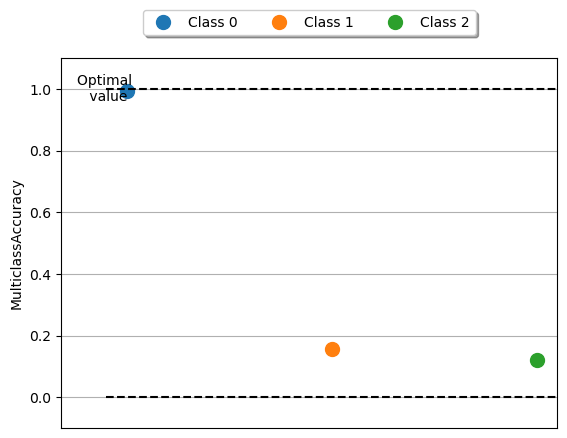

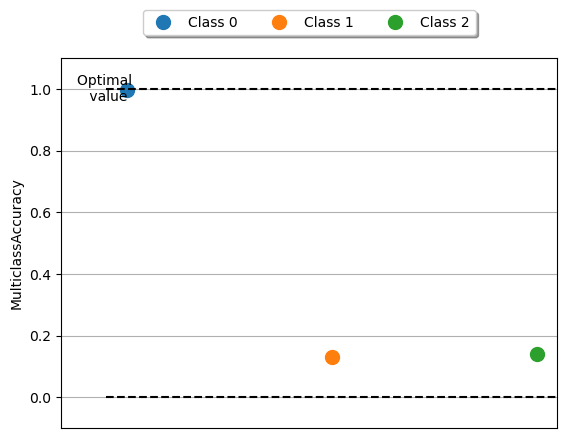

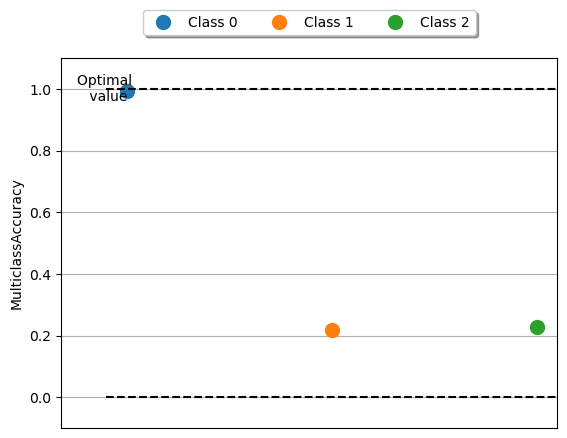

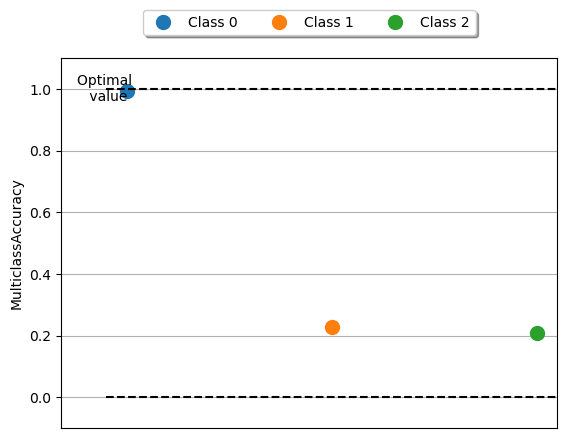

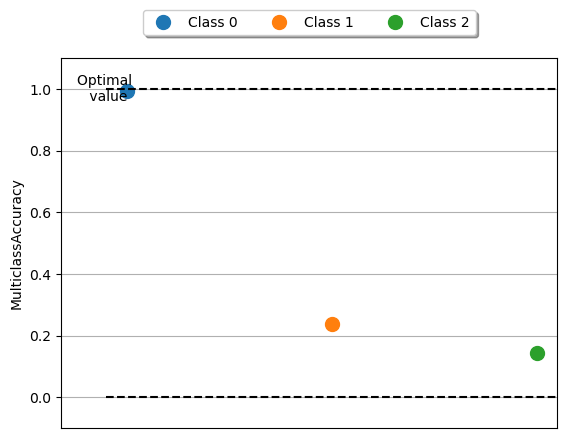

In [140]:
from torchmetrics.classification import MulticlassAccuracy, MulticlassF1Score
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

LOG_INTERVAL=6
epochs = 100
saveModel=False
SAVE_MODEL_INTERVAL=10
EARLY_STOPPING_PATIENCE = 3


use_amp = True

scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

log_dir = "./logs/"+model.name+"/" + datetime.now().strftime("%Y%m%d-%H%M%S")
summary_writer = SummaryWriter(log_dir)


# Instantiate a loss function.
# bceLoss = FocalLoss()
loss = torch.nn.CrossEntropyLoss()
lossVal = torch.nn.CrossEntropyLoss()

f1Metric = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetric = MulticlassAccuracy(num_classes=len(labelMapping)).to(device)

f1MetricVal = MulticlassF1Score(num_classes=len(labelMapping)).to(device)
accMetricVal = MulticlassAccuracy(num_classes=len(labelMapping), average=None).to(device)


def train(dataloader, model, lossFn, optimizer, epoch):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        with torch.autocast(device_type=device, dtype=torch.float16, enabled=use_amp):
            # Compute prediction error
            pred = model(X)
            loss = lossFn(pred, y)
        accMetric.update(pred, y)
        f1Metric.update(pred, y)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)

        if batch % LOG_INTERVAL == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}, Acc: {accMetric.compute():.4f}, F1: {f1Metric.compute():.4f}  [{current:>5d}/{size:>5d}]")
            summary_writer.add_scalar("Loss", loss, epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("Accuracy", accMetric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.add_scalar("F1", f1Metric.compute(), epoch*size//BATCH_SIZE+batch)
            summary_writer.flush()

@torch.no_grad()
def validate(dataloader, model, loss_fn, epoch):
    num_batches = len(dataloader)
    model.eval()
    valLoss = 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            valLoss += loss_fn(pred, y).item()
            accMetricVal.update(pred, y)
            f1MetricVal.update(pred, y)

    valLoss /= num_batches
    fig_, ax_ = accMetricVal.plot()
    fig_.savefig(f"./valPlots/acc_{t}.png")
    
    print(f"Validation: Loss {valLoss:>4f}, F1 {f1MetricVal.compute():.4f}  Accuracy {torch.mean(accMetricVal.compute()):.4f} \n")
    summary_writer.add_scalar("Val Loss", valLoss, epoch)
    summary_writer.add_scalar("Val Accuracy", torch.mean(accMetricVal.compute()), epoch)
    summary_writer.add_scalar("Val F1", f1MetricVal.compute(), epoch)
    summary_writer.flush()
    return valLoss

bestPerformance=99
bestEpoch=0

for t in np.arange(startEpoch, startEpoch + epochs, 1):
    print(f"Epoch {t+1}\n-------------------------------")
    train(trainLoader, model, loss, optimizer, t)
    valLoss=validate(valLoader, model, lossVal, t)
    # scheduler.step()
    if t%SAVE_MODEL_INTERVAL==0:
        print("LR: ", optimizer.param_groups[0]['lr'])
    if valLoss < bestPerformance:
        bestPerformance = valLoss
        print(f"New best performance: {bestPerformance:.4f}")
        bestF1=f1MetricVal.compute()
        bestEpoch=t
        bestWeights = model.state_dict()
    if t-bestEpoch>EARLY_STOPPING_PATIENCE:
        print(f"Early Stopping. {bestF1=}")
        break
    accMetric.reset()
    f1Metric.reset()
    accMetricVal.reset()
    f1MetricVal.reset()

print("Done!")

In [138]:
print(model.load_state_dict(bestWeights))

torch.save({
        'epoch': t,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        # "scaler": scaler.state_dict(),
        # 'scheduler_state_dict': scheduler.state_dict(),
        # 'loss': loss,
        }, os.path.join("./", f"{model.name}_{IMG_SIZE[0]}_F1_{bestF1:.3f}_CE_{bestPerformance:.3f}_epoch_{bestEpoch}.pt"))

<All keys matched successfully>
